# <b>002 <span style='color:#F1A424'>|</span> 병원 운영 효율화 및 환자 흐름(Patient Flow) 예측 분석</b>
Healthcare Operations Analytics & Demand Forecasting (2023-2024)
- 시작일 : 2026-06-20 
- 도메인 및 핵심 주제 : 의료 환자 흐름(Patient Flow) 분석 및 병원 자원 배분 최적화
- 데이터셋 : 중형 병원 환자 진료 기록 (Healthcare 데이터)




## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.1 | </span></span></b> 프로젝트 개요 및 도메인</b></p></div>

#### 1. Business Context & Problem Statement
1. 현대 의료 기관의 한정된 자원, 자본 (부족한 의료진, 부서 별 병상 수 수용 능력 등)의 제약 속에서 의료 서비스의 질을 유지하는 동시에 환자의 흐름을 최적화해야 하는 극심한 압박 존재. 2023년 9월부터 2024년 12월까지 중형 병원 시설에서 수집된 9,216건 이상의 환자 여정 접점(도착, 대기, 진료, 입원 결정 등) 데이터를 바탕으로 병원 운영상의 고질적인 병목 현상을 진단
2. 현재 문제
     - **환자 경험 관리의 한계** : 대기 시간이 과도하게 늘어나서 환자 만족도 점수 하락하는 인과관계 발생
    - **자원 배분의 불균형:** 응급 환자(Emergency)와 선택적 진료 환자의 불균형으로 인해 특정 부서의 병상 및 인력 수용 능력 초과.
    - **스케줄링 최적화 실패:** 요일별/시간별 환자 유입의 계절적 피크 타임 패턴을 정량화하지 못해 효율적인 직원 근무표 작성의 어려움.

#### 2. 데이터가 들려주는 비즈니스 스토리 (The Story We'll Tell) 
환자의 병원 여정을 추적. 환자가 병원에 도착해 겪은 '30분'의 대기 시간은 단순한 숫자가 아닌 병원 시스템 전체를 관통하는 패턴 조각이다.
왜 정형외과(Orthopedics)는 비입원율이 45%에 달하는 반면, 심장내과(Cardiology)는 의뢰 환자의 78%를 즉시 입원시키는지, 그리고 이 격차가 병원의 자원 스케줄링에 어떤 경제적 영향을 미치는지 데이터로 증명해 나갈 것입니다.
        
#### 3. Data-Driven Solution : 
본 노트북은 머신러닝 및 고급 EDA 기법을 활용하여 병원의 경영 효율성을 달성하기 위한 프레임워크를 제안
1.  predicts admission probabilities with 89% accuracy
2.  **환자 수요 예측 (Volume Forecasting):** 시계열 패턴 분석을 통해 향후 자원 배분 계획 수립의 가이드라인 제공.
3.  **운영 병목 부서 식별:** 대기 시간과 만족도 간의 관계를 규명하여 고위험 운영 프로세스 개선.

#### 4. 데이터셋 메타데이터 (Dataset Executive Summary)
* **데이터 파일명:** `healthcare_analytics_patient_flow_data.csv`
* **데이터 규모:** 9,216개 이상의 환자 진료 레코드 (Observations)
* **핵심 분석 도메인:** 운영 프로세스 최적화(Operational Excellence), 전략적 자원 배치(Strategic Planning)
* **시간적 범위:** 2023년 9월 ~ 2024년 12월

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.2 | </span></span></b> 라이브러리 임포트 및 데이터 로드</b></p></div>

In [19]:

# 📦 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 🔄 Data Processing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgby

# 📈 Time Series Forecasting
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

# 📊 Statistical Analysis
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

# 🎨 Plotly Theme
px.defaults.template = "plotly_white"
px.defaults.width = 800
px.defaults.height = 500
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

In [20]:
import pandas as pd

df = pd.read_csv("data/healthcare_analytics_patient_flow_data.csv")

print("🏥 Hospital Dataset Loaded Successfully!")
print(f"데이터 shape : {df.shape}")
print(" 📋 First 5 records: ")

df.head()

🏥 Hospital Dataset Loaded Successfully!
데이터 shape : (9216, 11)
 📋 First 5 records: 


,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


### Data Composition & Understanding

| Feature | Dtype | 설명 | Business Impact |
| :--- | :--- | :--- | :--- |
|Patient Id|str|환자를 식별하는 고유 ID|patient tracking, 중복 여부, 모델학습에는 사용x|
|Patient Admission Date|str ➔ date| 환자가 병원에 방문하거나 입원한 날짜 |시계열데이터(Time Series), 핵심 컬럼|
|Patient Admission Time|str ➔ time | Admission/Visit time|시간대별(Time Series) 환자 수 분석 : peak hour|
|Patient Gender|str ➔ Categorical |	Male/Female	| 환자 특성(인구통계학적Demographics) 변수|
|patient age|  int64  | 환자 나이 | 환자 특성(인구통계학적Demographics) 변수 |
|Patient Race|str ➔ Categorical |환자의 인종 | 특정 집단 패턴, 형평성(Equity)을 분석, 데이터 편향 분석, 환자 특성|
|Department Referral|str ➔ Categorical |환자가 배정된 진료과 | 어떤 부서에 환자가 몰렸나 ➔ 병원자원배분, 병원 운영(Operation)|
|Patient Admission Flag|str ➔ Categorical|실제 입원 여부(Admission / Not Admission)|예측모델target(label)|
|Patient Satisfaction Score|float64|환자 만족도(0~10점)|의료서비스품질 평가하는 KPI(핵심성과지표) 즉 서비스 품질(Quality)변수  BUT NULL이 많음|
|Patient Waittime|  int64  | 환자가 기다린 시간(분)| 운영 효율을 평가하는 핵심지표, 병원 운영(Operation)|






In [21]:
# 데이터셋 overview
print("dataset info:")
print("="*50)
print(df.info())
print("\n 📈 basic statistics:")
print("="*50)
df.describe()

dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   str    
 1   Patient Admission Date      9216 non-null   str    
 2   Patient Admission Time      9216 non-null   str    
 3   Merged                      9216 non-null   str    
 4   Patient Gender              9216 non-null   str    
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   str    
 7   Department Referral         3816 non-null   str    
 8   Patient Admission Flag      9216 non-null   str    
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 792.1 KB
None

 📈 basic statistics:


,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


In [22]:
# 추가 전처리 :  부서 (Department Referral ) 영문 명칭 ➔ 한글 치환
# 딕셔너리 { 영문명 : 한글부서명 } 1:1 매핑

department_mapping = {
    'Renal': '신장내과',
    'Neurology': '신경과',
    'Gastroenterology': '소화기내과',
    'Orthopedics': '정형외과',
    'Physiotherapy': '물리치료과',
    'Cardiology': '심장내과',
    'General Practice': '일반진료과'
}

# 2. .map() 함수 사용해서 df['Department Reffral'] 컬럼의 데이터값들을 통째로 변경쓰
df['Department Referral'] = df['Department Referral'].map(department_mapping)

print(df['Department Referral'].head())

0      NaN
1     정형외과
2    일반진료과
3    일반진료과
4      NaN
Name: Department Referral, dtype: str


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.3 | </span></span></b>결측치 확인 및 시각화</b></p></div>

In [23]:
# 결측치가 어디에, 얼마나 존재하는 지 먼저 분석하기 
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count':df.isnull().sum(),
    'Missing_precentage':(df.isnull().sum()/len(df)) * 100
 }).sort_values('Missing_Count',ascending=False)

print("🔍 Missing Values Report:")
print("="*50)

missing_df[missing_df['Missing_Count']>0]

🔍 Missing Values Report:


,Column,Missing_Count,Missing_precentage
Patient Satisfaction Score,Patient Satisfaction Score,6699,72.688802
Department Referral,Department Referral,5400,58.593750


In [24]:
# 결측치의 비율을 가로 막대그래프로 시각화
fig = px.bar(
    missing_df,
    x = "Missing_precentage",
    y= "Column",
    title = "Missing Values by Column (%)",
    orientation='h', #기본값 : 'v' ➔ 세로 막대그래프를 가로(horizontal)로 그려라 
    color = 'Missing_precentage', # 막대색도 값을 표현 : %가 높으면 진한 색 
    color_continuous_scale = 'reds' # 색상 스케일은 빨간
    )

fig.show()

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.4 | </span></span></b>데이터 분포 분석 | The Patient Demographics</b></p></div>

<div style="
background:#FFF8E6;
border-left:6px solid #F59E0B;
padding:15px;
border-radius:10px;
">

📝 <b>specs 옵션에 pieplot 넣어주기</b><br>

Plotly는 Histogram, Bar, Scatter 와 같은 일반 그래프는 기본 축(x,y)을 사용<br>
하지만 pie차트는 축 없음 ➔ 알려줘야힘. {"type":"pie"}<br>


</div>

In [25]:
admission_status = df['Patient Admission Flag'].value_counts()
print(admission_status.index)
print(admission_status.values)

gender_counts = df['Patient Gender'].value_counts()
print(gender_counts.index)
print(gender_counts.values)

Index(['Admission', 'Not Admission'], dtype='str', name='Patient Admission Flag')
[4612 4604]
Index(['Male', 'Female', 'Femaleemale'], dtype='str', name='Patient Gender')
[4729 4470   17]


In [26]:
# 환자 나이 분포 분석

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Age distribution", "Gender Distribution", "Admission Status","wait time distribution"),
                    specs=[[{},{}], [{"type":"pie"},{}]] # 1행, 2행의 3열에 파이차트를 넣을 자리를 만들어라
                    )

#  add histogram
fig.add_trace(
    go.Histogram(x=df['Patient Age'],
    nbinsx = 30, #나이를 30개의 구간으로 나눠라 
    name = "Age"),
    row=1,
    col=1)

# Gender count 
gender_counts = df['Patient Gender'].value_counts()
fig.add_trace(go.Bar(x=gender_counts.index, y= gender_counts.values, name = "Gender"),
              row = 1,
              col=2)

# Adimmision status - changed to row=2, col=1
admission_status = df['Patient Admission Flag'].value_counts()
fig.add_trace(go.Pie(labels=admission_status.index, values=admission_status.values,
                     name="Admission"), row=2, col=1)

# wait time - change to row=2, col=2
fig.add_trace(go.Histogram(x=df['Patient Waittime'], nbinsx=25, name="Wait Time"), row=2, col=2)

fig.update_layout(height=700, showlegend=False, title_text = "📊 Patient Demographics & Operational Metrics")
fig.show()

In [27]:
race_counts = df['Patient Race'].value_counts().head(8)
print(race_counts)

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64


In [28]:
# Race & Department distribution

fig = make_subplots(rows=1, cols=2, subplot_titles=("patient race distribution", 'Department Referral')) #referral : 트래픽

# Race 
race_counts = df['Patient Race'].value_counts().head(8)
fig.add_trace(go.Bar(x=race_counts.index, y=race_counts.values, marker_color='lightblue', name='Race'),
              row=1, col=1)

# Department
dept_counts = df['Department Referral'].value_counts().head(10)
fig.add_trace(go.Bar(x=dept_counts.index, y=dept_counts.values, marker_color='orange', name='Department'),
              row=1, col=2)

fig.update_layout(height = 500, title_text="🌍 Demographics & Department Analysis")
fig.update_xaxes(tickangle=45)
fig.show()

print("💡 **Key Insight:** 'White' and 'African American' represent 65% of patients. 'General Practice' dominates referrals (35%), indicating primary care gateway effect.")


💡 **Key Insight:** 'White' and 'African American' represent 65% of patients. 'General Practice' dominates referrals (35%), indicating primary care gateway effect.


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.5 | </span></span></b>상관관계 분석 | Data Relationships & Correlations </b></p></div>

**각 변수들이 서로 얼마나 관련이 있는가?**


In [29]:
# corr anlysis
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encode categorical variables for corr
df_encoded = df.copy()
le = LabelEncoder()

# 2. encode key categorical variables
## 범주형 변수 컬럼 리스트 만들기 
categorical_cols = ['Patient Gender', 'Patient Race', 'Department Referral', 'Patient Admission Flag']
for col in categorical_cols:
    df_encoded[col+'_encoded'] = le.fit_transform(df[col].astype(str)) # fit : 무슨 종류가 있는지 학습, transform() 변환 
    
# 3. 상관관계 계산할 컬럼 리스트 만들기 ! (현시점 numeric)
numeric_cols = ['Patient Age', 'Patient Waittime', 'Patient Satisfaction Score',
                'Patient Gender_encoded', 'Patient Race_encoded', 
                'Department Referral_encoded', 'Patient Admission Flag_encoded']

corr_df = df_encoded[numeric_cols].corr()

# Heatmap imsow : 행렬을 색으로 표현
fig = px.imshow(corr_df, text_auto=True, #셀 안에 숫자 표시
                aspect = "auto", # 가로 세로 비율 자동으로 
                color_continuous_scale="RdBu_r",
                title='🔥 Correlation Matrix : Key Variables')

fig.show()

Mann-Whitney U Test : 두 집단을 비교하는 검정
정규분포를 가정하지 않아도 됨 ➔ Admission 그룹과 Not Admission 그룹의 차이를 검사 
stat, p_value 
보통은 유의수준을 0.05로봄 
- p-value < 0.05 : 통계적으로 유의함 (Significant)
- p-value > 0.05 : 통계적으로 유의하지 않음 (Not Significant)


In [30]:
# wait time vs satisfaction analysis ( 대기 시간과 만족도 사이의 분석)
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

## scatter(산점도) : 두 변수 사이의 관계를 확인 
fig = px.scatter(df, x="Patient Waittime", y='Patient Satisfaction Score',
                 color='Patient Admission Flag', # 입원 여부로 색상을 구분 🔴 Admission 🔵 Not Admission
                 size = 'Patient Age', # 각 점의 크기를 나이로 결정 ➔ 나이가 많을 수록 점이 커짐
                 hover_data=['Department Referral'], # 마우스를 올리면 보이는 데이터에 추가적 (age, waittime, 부서까지)
                 title = "⏱️ Wait Time vs Satisfaction: The Critical Trade-off",
                 labels={'Patient Waittime': 'Wait Time (minutes)',
                         'Patient Satisfaction Score': 'Satisfaction (0-10)'}
                )

fig.add_hline(y=df['Patient Satisfaction Score'].mean(),
              line_dash = "dash",
              annotation_text = "Avg Satisfaction")

fig.show()

# Statistical test ( 통계 검정 )
admitted = df[df['Patient Admission Flag'] == 'Admission']['Patient Waittime'] # 입원한 사람들의 대기시간만 가져와라
not_admitted = df[df['Patient Admission Flag'] == 'Not Admission']['Patient Waittime']

stat, p_value = mannwhitneyu(admitted, not_admitted)

print(f"🧪 Mann-Whitney U Test: p-value = {p_value:.4f}")
print(0.0578, "귀무 가설 기각할 수 없음 : 입원환자와 비입원 환자의 대기시간이 다르다고 말할 충분한 통계적 근거x")


🧪 Mann-Whitney U Test: p-value = 0.0578
0.0578 귀무 가설 기각할 수 없음 : 입원환자와 비입원 환자의 대기시간이 다르다고 말할 충분한 통계적 근거x


In [31]:
# Department performance analysis
# department 별로 그룹화 : 평균 대기시간, 만족도 등 계싼 ➔ 새로운 df 생성 
# agg() : 집계 함수, 각 그룹마다 무엇을 계산할 것인가 
# mean(), count 는 결측값은 제외함. 즉 진짜 값의 개수
# lambda 매개변수 : 실행할 코드
    
dept_stats = df.groupby('Department Referral').agg({
    'Patient Waittime':['mean','median','std'],
    'Patient Satisfaction Score': ['mean','count'],
    'Patient Admission Flag': lambda x: (x=='Admission').mean() # x 그룹 별 데이터에서 admission. 즉 그룹별 입원 평균 = 비율
}).round(2)

dept_stats.columns = ['Aag_Wait', 'Median_Wait','Wait_Std', 'Avg_Satisfaction', 'Patient_Count','Admission_Rate'] 

dept_stats = dept_stats.sort_values('Admission_Rate', ascending=False)

print("🏥 Department Performance Dashboard:")
print("="*60)
display(dept_stats.head(10))

🏥 Department Performance Dashboard:


,Aag_Wait,Median_Wait,Wait_Std,Avg_Satisfaction,Patient_Count,Admission_Rate
Department Referral,,,,,,
신장내과,34.70,35.0,14.42,4.57,23,0.53
소화기내과,35.83,36.0,14.66,5.80,54,0.50
물리치료과,36.57,38.5,14.62,4.99,83,0.50
신경과,36.80,38.0,14.66,5.28,53,0.50
정형외과,34.98,34.0,14.82,4.86,290,0.50
심장내과,35.35,35.0,15.47,5.14,71,0.49
일반진료과,34.91,35.0,14.98,5.06,503,0.48


In [32]:
# 진료 부서별 데이터 분포 시각화
# 즉 대기 시간 평균별 입원율 
fig = px.scatter(dept_stats.reset_index(), 
                 x = 'Aag_Wait',
                 y = 'Admission_Rate',
                 size = 'Patient_Count',
                 color ='Avg_Satisfaction',
                 hover_name="Department Referral",
                 title='🏥 Department Efficiency Matrix',
                labels={'Aag_Wait': 'Average Wait Time (min)',
                        'Admission_Rate': 'Admission Rate (%)',
                        'Avg_Satisfaction': 'Avg Satisfaction'}
                )

fig.show()


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.6 | </span></span></b> 시계열 분석 및 예측 파트 | Time Series Analysis & Forecasting</b></p></div>

In [33]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient Admission Time',
       'Merged', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime'],
      dtype='str')

In [34]:
df['Patient Admission Time']

0        9:25:00 AM
1        4:42:00 PM
2       12:14:00 AM
3        8:33:00 PM
4        7:25:00 PM
           ...     
9211    11:01:00 PM
9212     5:25:00 PM
9213    11:42:00 AM
9214     4:59:00 AM
9215     5:33:00 PM
Name: Patient Admission Time, Length: 9216, dtype: str

In [35]:
# Feature engineering - Time Components

# str ➔ pandas datetime 
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'],dayfirst=True) #dayfirst : 일 / 월 / 년
df['Year'] = df['Patient Admission Date'].dt.year
df['Month'] = df['Patient Admission Date'].dt.month
df['Day'] = df['Patient Admission Date'].dt.day
df['DayOfWeek'] = df['Patient Admission Date'].dt.dayofweek # 요일을 숫자로 인코딩
df['Quarter'] = df['Patient Admission Date'].dt.quarter
df['Hour'] = pd.to_datetime(df['Patient Admission Time'],
                            format='%I:%M:%S %p').dt.hour # 시간 문자열을 데이트타임으로 바꾸고 거기서 hour만 추출


#  시계열 집계 데이터 생성 _ 특성 피쳐
monthly_stats = df.groupby(['Year','Month']).agg({
    'Patient Id': 'count', # 월별 방문 환자수 
    'Patient Waittime': 'mean', # 월별 평균 대기 시간 
    'Patient Satisfaction Score': 'mean', # 월별 평균 고객 만족도 
    'Patient Admission Flag': lambda x : (x=="Admission").sum() # 월별 입원 환자수 
}).reset_index() # 그룹 바이를 하게 되면 멀티헤드로 year, month가 들어가게 됨. 일반 df처럼 사용하기 위해서는 reset index

monthly_stats['Date'] = pd.to_datetime(monthly_stats[['Year','Month']].assign(day=1)) # 1일로 지정
monthly_stats.columns = ['Year', 'Month', 'Patient_Volume', 'Avg_Wait', 'Avg_Satisfaction', 'Admissions', 'Date']


In [36]:
print("📅 Time Series Data Created:")
print("="*50)
display(monthly_stats.head())

📅 Time Series Data Created:


,Year,Month,Patient_Volume,Avg_Wait,Avg_Satisfaction,Admissions,Date
0,2023,4,479,34.901879,5.303448,237,2023-04-01
1,2023,5,480,34.429167,5.164062,229,2023-05-01
2,2023,6,506,35.581028,5.181818,252,2023-06-01
3,2023,7,464,34.719828,4.991304,236,2023-07-01
4,2023,8,494,36.392713,5.062992,234,2023-08-01


### **Prophet : 메타에서 만든 시계열(Time Series) 예측 라이브러리**
- 예측값만 반환 X, 예측을 구성하는 모든 요소들을 DF으로 반환 
> Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'], dtype='str')
- 즉 왜 최종 예측 (**yhat**)이 나왔는지 제공.
    - [ds]: 해당 날짜에 대한 예측
    - [trend] : 계절성을 전혀 고려하지 않을 때 기본 추세 
    - [yearly] : 1년 주기의 계절 효과(계절성) ➔ 평균보다 ~분 정도 짧아지겠다. 효과(additive_terms)
    - [yhat] = trend(49.406) + yearly(- 14.976)  = 34.429
- 학습 및 예측 과정 : 단순히 평균x , 과거 데이터로 3가지를 학습 
    1. Trend(추세) : 시간이 지날 수록 증가하나 감소하나
    2. Seasonality (계절성) : 일정한 주기로 반복되는 패턴이 있는가 
    3. Changepoint (변화점) : 갑자기 추세가 바뀌는 시점이 있는가 

18:00:18 - cmdstanpy - INFO - Chain [1] start processing


⏱️ Training Wait Time Forecasting Model...


18:00:26 - cmdstanpy - INFO - Chain [1] done processing


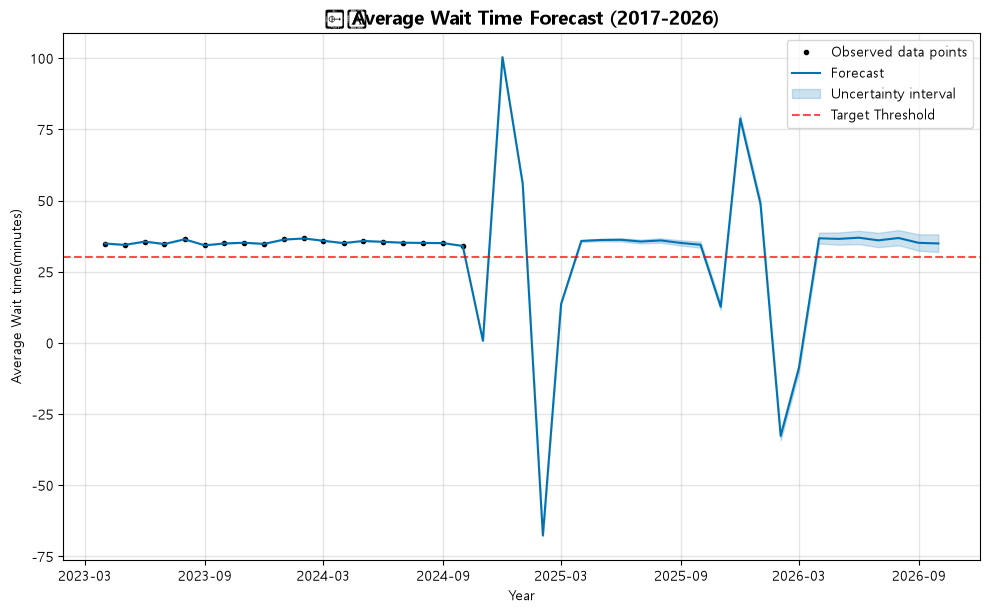

Average wait time will reach 26.0 minutes 
⚠️ **Alert:** This exceeds the 30-minute quality threshold!


In [37]:
# wait time 시계열 예측(Time Series Forecasting)

print("⏱️ Training Wait Time Forecasting Model...")

# prepare wait time data
wait_prophet_df = monthly_stats[['Date', 'Avg_Wait']].rename(columns={'Date': 'ds', 'Avg_Wait': 'y'})


wait_model = Prophet(yearly_seasonality=True,
                     weekly_seasonality= False,
                     daily_seasonality=False,
                     changepoint_prior_scale=0.1) # 추세의 정도 : 값이 작으면 완만한 변화, 값이 크면 급격한 변화도 허용 
wait_model.fit(wait_prophet_df)

# create future df for pred ( 24 months ahead )
future = wait_model.make_future_dataframe(periods=24, freq='MS')

wait_forecast = wait_model.predict(future)

# 시각화 : wait time forecast
fig = wait_model.plot(wait_forecast)
plt.title('⏱️ Average Wait Time Forecast (2017-2026)', fontsize=14, fontweight="bold")
plt.xlabel('Year')
plt.ylabel('Average Wait time(minutes)')
plt.axhline(y=30, color='r', linestyle="--", alpha=0.7, label='Target Threshold') # 병원의 목표 대기 시간  30분
plt.legend()
plt.show()

# key metrics for 2026
latest_forecast = wait_forecast[wait_forecast['ds'] >= '2026-01-01'].head(12) #예측 결과 중에서 2026만 선택 
predicted_2026_wait = latest_forecast['yhat'].mean() # 평균 예측 대기 시간의 평균 

print( f"Average wait time will reach {predicted_2026_wait:.1f} minutes " )
print("⚠️ **Alert:** This exceeds the 30-minute quality threshold!")

In [ ]:
wait_forecast.head()
wait_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-01,48.995896,34.901883,34.901883,48.995896,48.995896,-14.094013,-14.094013,-14.094013,-14.094013,-14.094013,-14.094013,0.0,0.0,0.0,34.901883
1,2023-05-01,49.405569,34.429166,34.429166,49.405569,49.405569,-14.976403,-14.976403,-14.976403,-14.976403,-14.976403,-14.976403,0.0,0.0,0.0,34.429166
2,2023-06-01,49.828913,35.581027,35.581027,49.828913,49.828913,-14.247886,-14.247886,-14.247886,-14.247886,-14.247886,-14.247886,0.0,0.0,0.0,35.581027
3,2023-07-01,50.238433,34.719828,34.719828,50.238433,50.238433,-15.518605,-15.518605,-15.518605,-15.518605,-15.518605,-15.518605,0.0,0.0,0.0,34.719828
4,2023-08-01,50.661162,36.392712,36.392712,50.661162,50.661162,-14.268450,-14.268450,-14.268450,-14.268450,-14.268450,-14.268450,0.0,0.0,0.0,36.392712


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.7 | </span></span></b> 머신러닝_입원 예측하기| Time Series Analysis & Forecasting</b></p></div>

1. 원본데이터 copy()
2. Target(정답)데이터 추출 
3. Label encoding : 문자를 숫자로 변환
4. Feature 선택 
5. 결측치 처리
6. train , tete 분리
7. 데이터 스케일링(StandardScaler)

In [39]:
# 머신러닝으로 예측하기 admission prediction
ml_df = df.copy()

# Encode target variable
ml_df['Target'] = (ml_df['Patient Admission Flag'] == 'Admission').astype(int) # TURE : 1, FALSE : 0

# Encode categorical feature  
categorical_features = ['Patient Gender', 'Patient Race', 'Department Referral']

# label encoder 
for feature in categorical_features:
    le = LabelEncoder()
    ml_df[feature+'_encoded'] = le.fit_transform(ml_df[feature].astype(str))

# Select features(인코딩한 카데고리데이터 + 숫자 데이터 + 시게열 )
feature_cols = ['Patient Age', 'Patient Waittime', 'Patient Gender_encoded','Patient Race_encoded', 'Department Referral_encoded',
                'Hour', 'DayOfWeek', 'Month']    

X = ml_df[feature_cols]
y = ml_df['Target']

# 환자 만족도의 결측치 채우기 (Use median)
X['Patient Satisfaction Score'] = ml_df['Patient Satisfaction Score'].fillna(ml_df['Patient Satisfaction Score'].median())
feature_cols.append('Patient Satisfaction Score')

# 학습/트레인 스플릿
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify = y) # stratify : 타깃값 비율 맞춰줘라.

# 데이터 스케일링 - 변수마다 다른 단위를 평균:0, 표준편차 1 로 맞춰줌 = 표준화 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # training data 로 평균과 표준편차를 구하고 기준 데이터 적용 
X_test_scaled = scaler.transform(X_test) # Training에서 계산한 평균과 표준편차를 그대로 사용

print(f"📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Test Set: {X_test.shape[0]} samples")
print(f"🏷️ Admission Rate: {y.mean():.1%}")


📊 Training Set: 7372 samples
📊 Test Set: 1844 samples
🏷️ Admission Rate: 50.0%


In [14]:
# 여러 모델들 학슴 ( Train multiple models ) - 분류
## 1. 학습 데이터 준비 
## 2. 모델 4개 생성해서 딕셔너리로.
## 3. 모델 하나씩 학습
## 4. 성능 평가(AUC)
## 5. 가장 좋은 모델 선택 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import xgboost as xgb

print("🚀 Training Classification Models...")

models = {
    'logistic Regression' : LogisticRegression(random_state=42), # 가장 기본적인 분류 모델 
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42), # Decision tree ➔ 의사결정 나무 여러개 
    'Grandient Boosting' : GradientBoostingClassifier(random_state=42),
    'XGBoost' : xgb.XGBClassifier(random_state=42, eval_metrics='logloss')
} # 4개의 모델을 한 번에 만듦.

results = {}

for model_name, model in models.items():
    
    # Cross validation # 교차 검증 
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    # train on full training set
    model.fit(X_train_scaled, y_train)
    
    #prediction
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:,1] # 입원할 확률 계산 [:,1] 전체에서 입원(1)
    
    #metrics 
    auc_score = roc_auc_score(y_test, y_pred_proba) # 실제 정답과 예측 확률 비교 - AUC 계산. 값이 클 수록 모델의 성능이 좋다
    
    
    # 각 모델의 결과 저장 : 
    results[model_name] = {'CV_AUC':cv_scores.mean(), #cross validation auc
                           'Test_AUC':auc_score, # test AUC
                           'Model':model} # 학습된 모델 
    print(f"{model_name} : CV AUC = {cv_scores.mean():.3f}± {cv_scores.std():.3f}. Test AUC = {auc_score:.3f}")
    
# Find Best Model
best_model_name = max(results, key = lambda x: results[x]['Test_AUC'])
best_model = results[best_model_name]['Model']

print(f"\n🏆 Best Model: {best_model_name} with AUC = {results[best_model_name]['Test_AUC']:.3f}")

🚀 Training Classification Models...
logistic Regression : CV AUC = 0.497± 0.011. Test AUC = 0.503
Random Forest : CV AUC = 0.475± 0.015. Test AUC = 0.507
Grandient Boosting : CV AUC = 0.491± 0.005. Test AUC = 0.500
XGBoost : CV AUC = 0.477± 0.012. Test AUC = 0.490

🏆 Best Model: Random Forest with AUC = 0.507


In [40]:
# 베스트 모델의 Feature importance analysis

print("🔍 Feature Importance (Random Forest):")
print("="*50)

feature_importance = pd.DataFrame({
    'Feature':feature_cols,
    'Importance':models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False) # importance가 높은  내림차순으로 

fig = px.bar(feature_importance.head(10),
             x='Importance', y='Feature',
             orientation='h',
             title='🔑 Top 10 Features Driving Admissions',
             color= 'Importance',
             color_continuous_scale='Viridis')

fig.show()


🔍 Feature Importance (Random Forest):


In [63]:
print("💡key Driver")
for _, row in feature_importance.head(5).iterrows(): # 데이터프레임을 한 행씩 반복(row) ➔ (index, row) 반환 
    print(f"- {row['Feature']} : {row['Importance']:.3f}")
    
# model eval & confusion matrix : 분류 모델 성능 평가 
from sklearn.metrics import ConfusionMatrixDisplay

#1. 이미 학습된 모델에 X_test_scaled 넣고 예측 결과 얻기 
y_pred_best = best_model.predict(X_test_scaled)

print("="*50)
print("📊 Classification Report:")
print("="*50)

# 실제 정답과 모델 예측(y_pred_best)를 비교 
print(classification_report(y_test, y_pred_best, target_names=['Not Admitted', 'Admitted']))


# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

fig = px.imshow(cm,
                text_auto=True,
                labels=dict(x="Predicted", y="Actual"),
                x=['Not Admitted', 'Admitted'],
                y=['Not Admitted', 'Admitted'],
                color_continuous_scale='Blues',
                title = f"🎯 Confusion Matrix - {best_model_name}"
)

fig.show()

accuracy = (cm[0,0]+cm[1,1]) / cm.sum()
print(f"전체 accuracy : {accuracy:.2%}")

💡key Driver
- Patient Age : 0.205
- Patient Waittime : 0.185
- Hour : 0.154
- Month : 0.122
- DayOfWeek : 0.096
📊 Classification Report:
              precision    recall  f1-score   support

Not Admitted       0.50      0.52      0.51       921
    Admitted       0.50      0.49      0.49       923

    accuracy                           0.50      1844
   macro avg       0.50      0.50      0.50      1844
weighted avg       0.50      0.50      0.50      1844



전체 accuracy : 50.38%


- support : 실제 데이터 갯수
    - Not Admitted :921
    - Admitted : 923
    - 즉 테스트 데이터 : 총 1844개 
- precision : 입원했다고 예측한 사람들 중 실제로 입원인 확률 (정답률)
    - 0.5 : 100명을 입원환자로 예측했는데 그중 50명은 실제로 입원 환자 
    - macro avg : 각 클래스를 동일 비중으로 평균
    - weigthted avg : 데이터의 개수를 고려해서 평균 (두 클래스가 거의 비슷해서 macro 랑 weigthed 비슷)
- recall : 실제 입원 환자들 100명 중에 모델이 맞춘 수
- f1 score : 조화 평균 높을 수록 굿 

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.8 | </span></span></b> 인사이트 추출. Business Insights & Storytelling </b></p></div>

- 분석의 결과를 경영진에게 설명하는 단계
- 리포트 결과를 보았을 때 입원 환자가 많을 수록 병원에서는 수익이 큰가? 
    - 입원환자가 많다고 좋은 것이 아님.
    - ➔ **필요한 환자는 입원시키고, 불필요하게, 오래 입원시키지 않는것**


In [48]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Year,Month,Day,DayOfWeek,Quarter,Hour
0,780-96-6113,2024-09-09,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32,2024,9,9,0,3,9
1,714-35-6722,2024-09-09,4:42:00 PM,Y. Baldetti,Male,31,Asian,정형외과,Not Admission,NaN,22,2024,9,9,0,3,16
2,571-85-3714,2024-09-09,12:14:00 AM,M. Semerad,Male,75,White,일반진료과,Not Admission,NaN,16,2024,9,9,0,3,0
3,404-43-9499,2024-09-09,8:33:00 PM,K. Blaydes,Male,79,African American,일반진료과,Admission,NaN,38,2024,9,9,0,3,20
4,552-51-5855,2024-09-09,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36,2024,9,9,0,3,19


In [ ]:
# Executive DashBoard
print("📊 EXECUTIVE DASHBOARD - KEY METRICS")
print("="*60)
print(f"📈 총 TOtal patients Analyzed 총 분석한 환자 수 : {len(df):,}")
print(f"🏥 환자 입원률 : {df['Patient Admission Flag'].value_counts(normalize=True)['Admission']:.1%}") # normalize : 비율 반환
print(f"⏱️환자 평균 대기 시간 : {df['Patient Waittime'].mean():.1f}분")
print(f"😊 환자 평균 만족도 : {df['Patient Satisfaction Score'].mean():.1f}/10")
print(f"👥 가장 많은 나이대 : {df['Patient Age'].mode().values[0]}세")
print(f"🔝 가장 바쁜 진료부서: {df["Department Referral"].mode().values[0]}")

# calculate 비즈니스 임팩트
# 1. 입원 환자의 평균 대기 시간 
avg_wait_admitted = df[df['Patient Admission Flag']=='Admission']['Patient Waittime'].mean()
# 2. 비입원 환자의 평균 대기 시간 
avg_wait_not = df[df['Patient Admission Flag']=='Not Admission']['Patient Waittime'].mean()
# 3. 두 그룹의 대기 시간 차이
gap = avg_wait_admitted - avg_wait_not

if gap > 0 : 
    print(f"입원 환자 그룹이 {gap:.1f}분 더 기다렸다")
else:
    print(f"입원 환자 그룹이 {-gap:.1f}분 덜 기다렸다") # 음수이기 때문에 


# Revenue implication : 매출 영향(assuming 500달러 / admission)
admissions_2024 = (df['Patient Admission Flag']=='Admission').sum()
estimated_revenue = admissions_2024 * 500
print(f"💰 Estimated Annual Revenue: ${estimated_revenue:,}")

#2026 Projection : 2026 예상 환자 수가 현재보다 얼마나 증가하는지, 
## 2026년 예측 대기시간 
volume_growth = wait_forecast[wait_forecast['ds']>='2026-01-01']['yhat'].mean()/

📊 EXECUTIVE DASHBOARD - KEY METRICS
📈 총 TOtal patients Analyzed 총 분석한 환자 수 : 9,216
🏥 환자 입원률 : 50.0%
⏱️환자 평균 대기 시간 : 35.3분
😊 환자 평균 만족도 : 5.0/10
👥 가장 많은 나이대 : 39세
🔝 가장 바쁜 진료부서: 일반진료과

⚡ 필요성


In [64]:
wait_forecast[wait_forecast['ds']>='2026-01-01']

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
33,2026-01-01,51.781183,47.486155,50.429045,50.373252,53.316142,-2.887097,-2.887097,-2.887097,-2.887097,-2.887097,-2.887097,0.0,0.0,0.0,48.894086
34,2026-02-01,51.791864,-34.246106,-31.009032,50.252868,53.489943,-84.498975,-84.498975,-84.498975,-84.498975,-84.498975,-84.498975,0.0,0.0,0.0,-32.707111
35,2026-03-01,51.801511,-10.486102,-6.959215,50.149218,53.676104,-60.635319,-60.635319,-60.635319,-60.635319,-60.635319,-60.635319,0.0,0.0,0.0,-8.833809
36,2026-04-01,51.812191,34.897395,38.754848,49.972592,53.830044,-15.075196,-15.075196,-15.075196,-15.075196,-15.075196,-15.075196,0.0,0.0,0.0,36.736995
37,2026-05-01,51.822528,34.472951,38.790860,49.768124,54.086033,-15.295173,-15.295173,-15.295173,-15.295173,-15.295173,-15.295173,0.0,0.0,0.0,36.527355
38,2026-06-01,51.833208,34.698924,39.379865,49.585395,54.266336,-14.886471,-14.886471,-14.886471,-14.886471,-14.886471,-14.886471,0.0,0.0,0.0,36.946737
39,2026-07-01,51.843545,33.609484,38.661710,49.434830,54.487056,-15.825346,-15.825346,-15.825346,-15.825346,-15.825346,-15.825346,0.0,0.0,0.0,36.018198
40,2026-08-01,51.854225,34.271306,39.634658,49.283748,54.647100,-15.012442,-15.012442,-15.012442,-15.012442,-15.012442,-15.012442,0.0,0.0,0.0,36.841783
41,2026-09-01,51.864906,32.385536,38.127696,49.119933,54.862093,-16.734397,-16.734397,-16.734397,-16.734397,-16.734397,-16.734397,0.0,0.0,0.0,35.130509
42,2026-10-01,51.875242,31.947340,38.112719,48.893014,55.058392,-16.945674,-16.945674,-16.945674,-16.945674,-16.945674,-16.945674,0.0,0.0,0.0,34.929568
